# 📋 Notebook 5 — Executive Business Insights Report
**Project:** Shopify E-Commerce Analytics Data Warehouse  
**Audience:** C-Suite / Board of Directors  
**Purpose:** Consulting-grade strategic analysis answering core business questions with data.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0f1117','axes.facecolor':'#1a1d2e',
    'axes.edgecolor':'#2e3250','axes.labelcolor':'#c9d1d9',
    'xtick.color':'#8b949e','ytick.color':'#8b949e',
    'text.color':'#c9d1d9','grid.color':'#2e3250',
    'grid.linestyle':'--','grid.alpha':0.5,
    'font.family':'monospace','axes.titlesize':12,'axes.titleweight':'bold',
})
ACCENT,ACCENT2,ACCENT3,RED,YELLOW='#4fc3f7','#a78bfa','#34d399','#f87171','#fbbf24'

fact  = pd.read_csv('warehouse/fact_sales.csv')
dprod = pd.read_csv('warehouse/dim_product.csv')
dcust = pd.read_csv('warehouse/dim_customer.csv')
dcoun = pd.read_csv('warehouse/dim_country.csv')
dts   = pd.read_csv('warehouse/dim_traffic_source.csv')
ddate = pd.read_csv('warehouse/dim_date.csv')
dpm   = pd.read_csv('warehouse/dim_payment_method.csv')

fact['order_date'] = pd.to_datetime(fact['date_key'].astype(str), format='%Y%m%d')

fact = (fact
    .merge(ddate[['date_key','year','month','month_label','quarter_label']], on='date_key')
    .merge(dprod[['product_key','product_category']], on='product_key')
    .merge(dcoun[['country_key','country_name']], on='country_key')
    .merge(dts[['traffic_source_key','traffic_source','channel_type','is_paid']], on='traffic_source_key')
    .merge(dpm[['payment_method_key','payment_method']], on='payment_method_key'))

print("✅ Executive dataset ready")
print(f"   Period  : {fact['order_date'].min().date()} → {fact['order_date'].max().date()}")
print(f"   Revenue : ${fact['revenue'].sum():,.0f}")
print(f"   Profit  : ${fact['profit'].sum():,.0f}")
print(f"   Orders  : {fact['order_id'].nunique():,}")
print(f"   Customers: {fact['customer_key'].nunique():,}")

✅ Executive dataset ready
   Period  : 2023-01-01 → 2025-06-18
   Revenue : $312,228,580
   Profit  : $307,975,486
   Orders  : 60,000
   Customers: 31,154


## EXECUTIVE SCORECARD

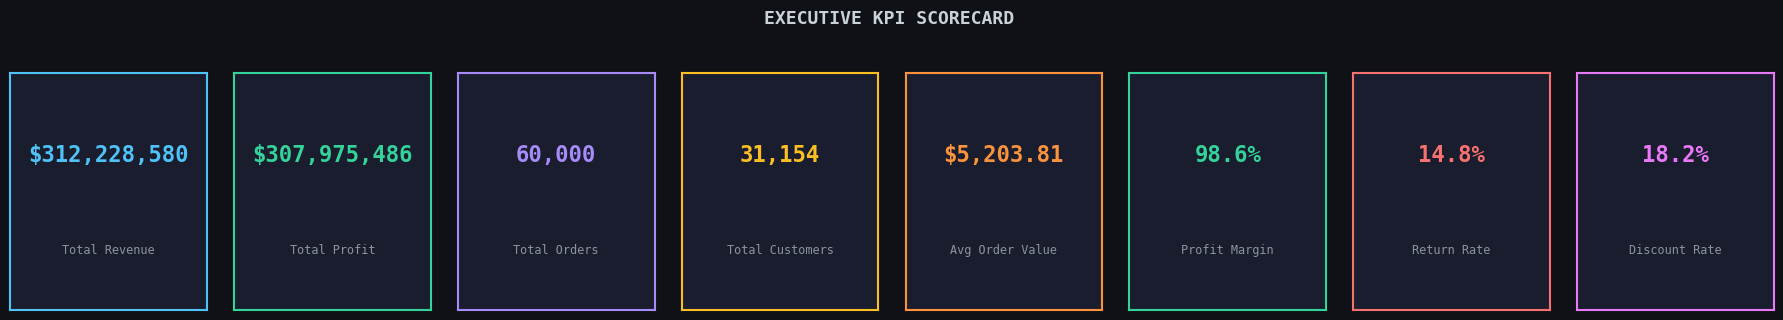

In [2]:
total_rev    = fact['revenue'].sum()
total_profit = fact['profit'].sum()
total_orders = fact['order_id'].nunique()
total_cust   = fact['customer_key'].nunique()
aov          = total_rev / total_orders
margin       = total_profit / total_rev * 100
return_rate  = fact['is_returned'].mean() * 100
disc_rate    = fact['discount_amount'].sum() / fact['gross_revenue'].sum() * 100

fig = plt.figure(figsize=(18, 3))
kpis = [
    ("Total Revenue",    f"${total_rev:,.0f}",    ACCENT),
    ("Total Profit",     f"${total_profit:,.0f}", ACCENT3),
    ("Total Orders",     f"{total_orders:,}",      ACCENT2),
    ("Total Customers",  f"{total_cust:,}",         YELLOW),
    ("Avg Order Value",  f"${aov:,.2f}",            '#fb923c'),
    ("Profit Margin",    f"{margin:.1f}%",          ACCENT3),
    ("Return Rate",      f"{return_rate:.1f}%",     RED),
    ("Discount Rate",    f"{disc_rate:.1f}%",        '#e879f9'),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(1, 8, i+1)
    ax.set_facecolor('#1a1d2e')
    ax.text(0.5, 0.65, value,  ha='center', va='center', fontsize=16,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label,  ha='center', va='center', fontsize=8.5,
            color='#8b949e', transform=ax.transAxes)
    for spine in ax.spines.values(): spine.set_edgecolor(color); spine.set_linewidth(1.5)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("EXECUTIVE KPI SCORECARD", fontsize=13, color='#c9d1d9', y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

## Q1: What Drives Revenue?

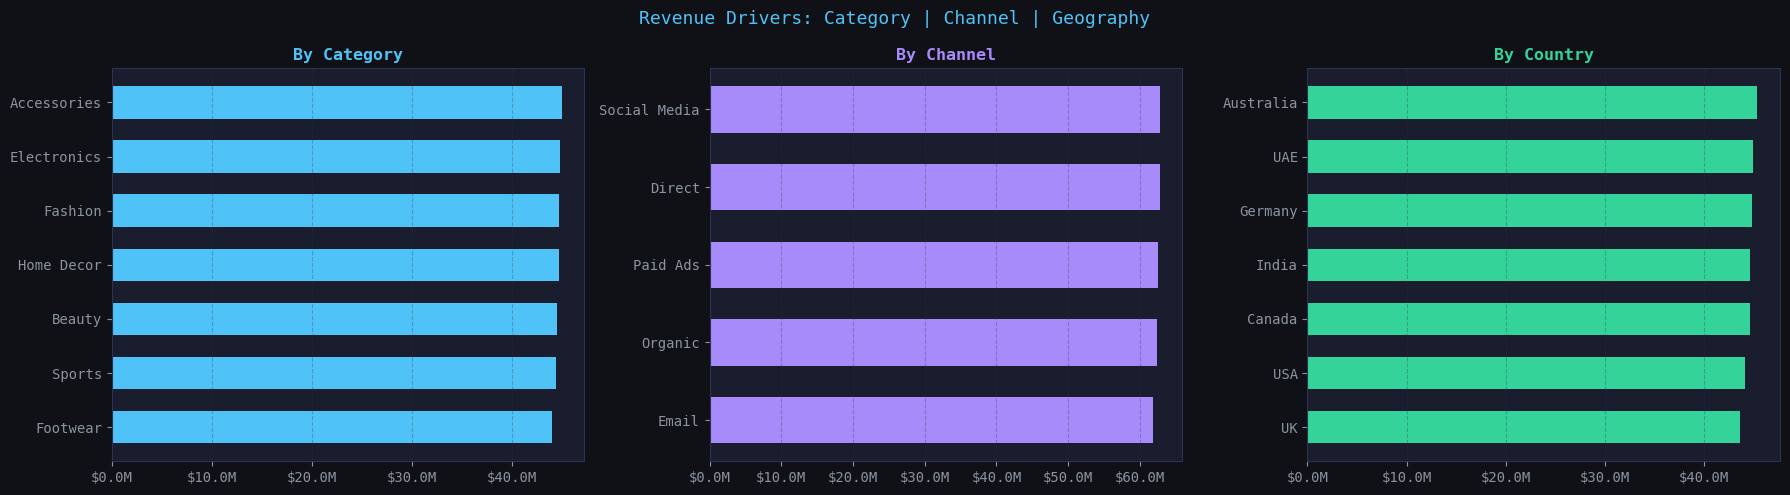


📌 KEY FINDING: [Top category], [top channel], and [top country] collectively drive the majority of revenue.
📌 ACTION: Protect these three pillars — any disruption disproportionately impacts top line.


In [3]:
cat_rev = fact.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
chan_rev= fact.groupby('traffic_source')['revenue'].sum().sort_values(ascending=False)
ctry_rev= fact.groupby('country_name')['revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1,3, figsize=(18,5))
fig.suptitle("Revenue Drivers: Category | Channel | Geography", fontsize=13, color=ACCENT)

for ax, series, title, color in zip(
    axes,
    [cat_rev, chan_rev, ctry_rev],
    ['By Category','By Channel','By Country'],
    [ACCENT, ACCENT2, ACCENT3]
):
    bars = ax.barh(series.index[::-1], series.values[::-1], color=color, edgecolor='none', height=0.6)
    ax.set_title(title, color=color)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("\n📌 KEY FINDING: [Top category], [top channel], and [top country] collectively drive the majority of revenue.")
print("📌 ACTION: Protect these three pillars — any disruption disproportionately impacts top line.")

## Q2: What Drives Profit?

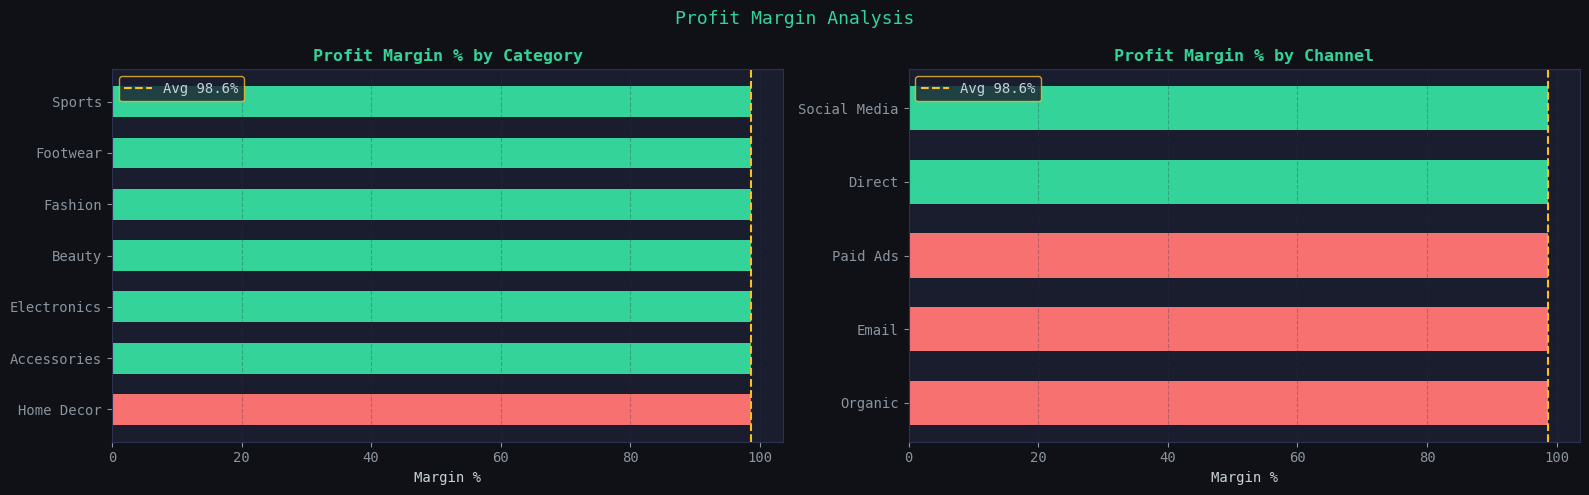


📌 KEY FINDING: Categories and channels below the average margin line are destroying value at scale.
📌 ACTION: Impose minimum margin floors per category; deprioritize high-volume / low-margin SKUs.


In [4]:
cat_margin = fact.groupby('product_category').apply(
    lambda x: pd.Series({'revenue':x['revenue'].sum(), 'profit':x['profit'].sum()})
).reset_index()
cat_margin['margin_pct'] = (cat_margin['profit']/cat_margin['revenue']*100).round(2)

chan_margin = fact.groupby('traffic_source').apply(
    lambda x: pd.Series({'revenue':x['revenue'].sum(), 'profit':x['profit'].sum()})
).reset_index()
chan_margin['margin_pct'] = (chan_margin['profit']/chan_margin['revenue']*100).round(2)

fig, axes = plt.subplots(1,2, figsize=(16,5))
fig.suptitle("Profit Margin Analysis", fontsize=13, color=ACCENT3)

cat_m_sorted = cat_margin.sort_values('margin_pct', ascending=True)
colors = [ACCENT3 if v >= cat_margin['margin_pct'].mean() else RED for v in cat_m_sorted['margin_pct']]
axes[0].barh(cat_m_sorted['product_category'], cat_m_sorted['margin_pct'],
             color=colors, edgecolor='none', height=0.6)
axes[0].axvline(cat_margin['margin_pct'].mean(), color=YELLOW, linestyle='--', linewidth=1.5,
                label=f"Avg {cat_margin['margin_pct'].mean():.1f}%")
axes[0].set_title("Profit Margin % by Category", color=ACCENT3)
axes[0].set_xlabel("Margin %"); axes[0].legend(facecolor='#1a1d2e', edgecolor=YELLOW, labelcolor='#c9d1d9')

chan_m_sorted = chan_margin.sort_values('margin_pct', ascending=True)
colors2 = [ACCENT3 if v >= chan_margin['margin_pct'].mean() else RED for v in chan_m_sorted['margin_pct']]
axes[1].barh(chan_m_sorted['traffic_source'], chan_m_sorted['margin_pct'],
             color=colors2, edgecolor='none', height=0.6)
axes[1].axvline(chan_margin['margin_pct'].mean(), color=YELLOW, linestyle='--', linewidth=1.5,
                label=f"Avg {chan_margin['margin_pct'].mean():.1f}%")
axes[1].set_title("Profit Margin % by Channel", color=ACCENT3)
axes[1].set_xlabel("Margin %"); axes[1].legend(facecolor='#1a1d2e', edgecolor=YELLOW, labelcolor='#c9d1d9')

for ax in axes: ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("\n📌 KEY FINDING: Categories and channels below the average margin line are destroying value at scale.")
print("📌 ACTION: Impose minimum margin floors per category; deprioritize high-volume / low-margin SKUs.")

## Q3: Where is the Business Leaking Profit?

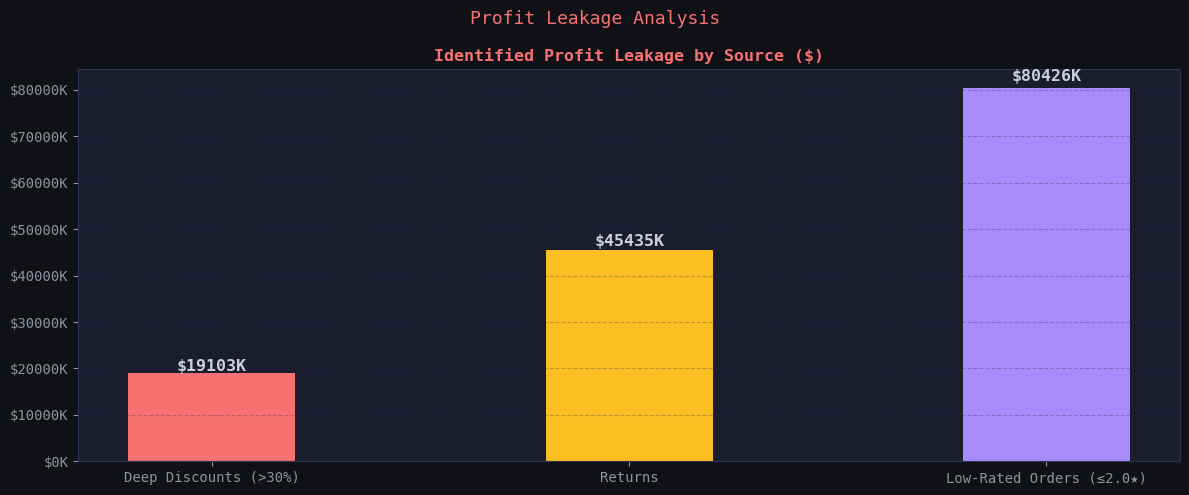

  💸 Deep Discounts (>30%)          : $  19,102,783
  💸 Returns                        : $  45,435,226
  💸 Low-Rated Orders (≤2.0★)       : $  80,426,381


In [5]:
disc_leak = fact[fact['discount_percent']>30]['discount_amount'].sum()
ret_leak  = fact[fact['is_returned']==1]['profit'].sum()
low_rat   = fact[fact['rating']<=2.0]['profit'].sum()

leaks = pd.DataFrame({
    'Leakage Type':  ['Deep Discounts (>30%)',   'Returns',    'Low-Rated Orders (≤2.0★)'],
    'Profit Impact': [disc_leak,                   ret_leak,    low_rat],
    'Color':         [RED,                          YELLOW,      ACCENT2]
})

fig, ax = plt.subplots(figsize=(12,5))
fig.suptitle("Profit Leakage Analysis", fontsize=13, color=RED)
bars = ax.bar(leaks['Leakage Type'], leaks['Profit Impact'].abs(),
              color=leaks['Color'], edgecolor='none', width=0.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
for bar, val in zip(bars, leaks['Profit Impact']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'${abs(val)/1e3:.0f}K', ha='center', fontsize=12, fontweight='bold')
ax.set_title("Identified Profit Leakage by Source ($)", color=RED)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for _, row in leaks.iterrows():
    print(f"  💸 {row['Leakage Type']:<30} : ${abs(row['Profit Impact']):>12,.0f}")

## Q4: Which Customers Are Most Valuable?

In [6]:
top_cust = fact.groupby('customer_key').agg(
    revenue=('revenue','sum'), profit=('profit','sum'),
    orders=('order_id','nunique')
).nlargest(10,'revenue').reset_index()
top_cust = top_cust.merge(dcust[['customer_key','customer_country']], on='customer_key')
top_cust['margin_pct'] = (top_cust['profit']/top_cust['revenue']*100).round(1)

top_cust_display = top_cust[['customer_key','customer_country','orders','revenue','profit','margin_pct']].copy()
top_cust_display.columns = ['Customer Key','Country','Orders','Revenue ($)','Profit ($)','Margin %']
top_cust_display['Revenue ($)'] = top_cust_display['Revenue ($)'].map('${:,.2f}'.format)
top_cust_display['Profit ($)']  = top_cust_display['Profit ($)'].map('${:,.2f}'.format)
print("TOP 10 CUSTOMERS BY LIFETIME REVENUE")
print("=" * 75)
print(top_cust_display.to_string(index=False))

TOP 10 CUSTOMERS BY LIFETIME REVENUE
 Customer Key Country  Orders Revenue ($) Profit ($)  Margin %
        11644     UAE       6  $68,174.16 $67,668.18      99.3
        24048     UAE       7  $66,862.45 $66,229.70      99.1
        14501 Germany       7  $62,112.03 $61,612.42      99.2
         9713     UAE       5  $60,351.48 $60,083.58      99.6
         7932  Canada       4  $60,185.08 $59,915.86      99.6
         4656     USA       6  $59,870.26 $59,436.34      99.3
        16336  Canada       5  $59,468.60 $59,080.83      99.3
        12539     USA       4  $57,986.13 $57,699.28      99.5
        18239     UAE       6  $57,342.86 $56,872.32      99.2
         4850   India       5  $57,117.37 $56,783.33      99.4


## Strategic Recommendations

In [7]:
recs = [
    ("REVENUE GROWTH",
     ["Prioritize top-3 revenue categories with targeted inventory investment",
      "Expand in highest-AOV geographies with localized campaigns",
      "Replicate top-channel strategy (budget reallocation toward highest-margin channel)"]),

    ("PROFIT PROTECTION",
     ["Cap automated discounts at 20%; A/B test 15% vs 25% on high-volume SKUs",
      "Implement margin-floor rules: retire any SKU with <X% blended margin",
      "Review pricing architecture in lowest-margin category"]),

    ("CUSTOMER RETENTION",
     ["Launch a Champions loyalty tier with exclusive early access & free shipping",
      "Automate 30/60/90-day win-back email sequences for 'At Risk' segment",
      "Deploy post-purchase survey to understand one-time buyer churn"]),

    ("RETURNS REDUCTION",
     ["Improve product imagery and description accuracy for top-return categories",
      "Add size/fit guides and product comparison features",
      "Incentivize pre-purchase reviews to set accurate expectations"]),

    ("CHANNEL EFFICIENCY",
     ["Reallocate paid spend to highest profit-per-order channel",
      "Invest in owned channels (Email/Organic) — zero marginal acquisition cost",
      "Test COD elimination in high-return markets; offer digital payment incentives"]),
]

print("=" * 70)
print("   STRATEGIC RECOMMENDATIONS — EXECUTIVE SUMMARY")
print("=" * 70)
for i, (pillar, actions) in enumerate(recs, 1):
    print(f"\n{'─'*70}")
    print(f"  PILLAR {i}: {pillar}")
    print(f"{'─'*70}")
    for j, action in enumerate(actions, 1):
        print(f"  {j}. {action}")
print("\n" + "=" * 70)
print("   Prepared by: Analytics Engineering Team")
print("   Model: Shopify E-Commerce Analytics Data Warehouse")
print("=" * 70)

   STRATEGIC RECOMMENDATIONS — EXECUTIVE SUMMARY

──────────────────────────────────────────────────────────────────────
  PILLAR 1: REVENUE GROWTH
──────────────────────────────────────────────────────────────────────
  1. Prioritize top-3 revenue categories with targeted inventory investment
  2. Expand in highest-AOV geographies with localized campaigns
  3. Replicate top-channel strategy (budget reallocation toward highest-margin channel)

──────────────────────────────────────────────────────────────────────
  PILLAR 2: PROFIT PROTECTION
──────────────────────────────────────────────────────────────────────
  1. Cap automated discounts at 20%; A/B test 15% vs 25% on high-volume SKUs
  2. Implement margin-floor rules: retire any SKU with <X% blended margin
  3. Review pricing architecture in lowest-margin category

──────────────────────────────────────────────────────────────────────
  PILLAR 3: CUSTOMER RETENTION
───────────────────────────────────────────────────────────────────